# PEM hydrogen production rate

Goal: estimate how much hydrogen the electrolyzer produces from electrical input.

For each charge-discharge test I use the charge part and calculate:

input_charge_C = integral(I_charge dt)

input_energy_J = integral(V_charge I_charge dt)

hydrogen_per_J = measured_hydrogen_volume_mL / input_energy_J

The volume readings are manual, so I compare all tests and use an aggregate value rather than trusting
one single test.


In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes the notebook work both from the repo root and from its own folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load volume readings and test files


In [9]:
readings_file = PROJECT_ROOT / "data/PEM_test/volume_readings/readings.csv"
pem_folder = PROJECT_ROOT / "data/PEM_test/charge_discharge"

volume_readings = pd.read_csv(readings_file)
test_files = sorted(pem_folder.glob("discharge_*s_r1.csv"))

display(volume_readings)
print("Test files:", len(test_files))


,current_A,time_s,volume_mL
0,0.2,30,0.2
1,0.2,60,1.6
2,0.2,120,3.0
3,0.3,30,1.6
4,0.3,60,2.2
5,0.3,120,4.2
6,0.4,30,2.2
7,0.4,60,4.0
8,0.4,120,6.0


Test files: 9


## 2. Extract the active electrolysis part of each file


In [10]:
def load_pem_charge_part(file):
    df = pd.read_csv(file)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()
    df["pem_voltage_V"] = df["ina4_bus_V"] - 0.064
    df["pem_current_A"] = 0.843 * (df["ina4_current_mA"] / 1000) + 0.001
    df["pem_charge_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]

    charge = df[(df["scenario"] == 3) & (df["pem_current_A"] > 0.05)].copy()
    charge["charge_time_s"] = charge["time_s"] - charge["time_s"].iloc[0]
    return charge

charge_tests = {file.name: load_pem_charge_part(file) for file in test_files}

first_name = test_files[0].name
display(charge_tests[first_name].head())


,timestamp,scenario,mode,K1,K2,K3,K4,K5,K6,K7,ina1_ok,ina1_bus_V,ina1_current_mA,ina1_power_mW,ina1_shunt_mV,ina2_ok,ina2_bus_V,ina2_current_mA,ina2_power_mW,ina2_shunt_mV,ina3_ok,ina3_bus_V,ina3_current_mA,ina3_power_mW,ina3_shunt_mV,ina4_ok,ina4_bus_V,ina4_current_mA,ina4_power_mW,ina4_shunt_mV,time_s,pem_voltage_V,pem_current_A,pem_charge_power_W,charge_time_s
5,2026-04-30 09:11:12,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6525,198.525,526.875,19.8525,1,1.6662,236.175,393.750,23.6175,6.0,1.6022,0.200096,0.320593,0.0
6,2026-04-30 09:11:13,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6762,198.550,531.250,19.8550,1,1.6888,236.175,398.750,23.6175,7.0,1.6248,0.200096,0.325115,1.0
7,2026-04-30 09:11:14,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6775,198.575,531.875,19.8575,1,1.6888,236.200,398.750,23.6200,8.0,1.6248,0.200117,0.325149,2.0
8,2026-04-30 09:11:15,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6762,198.575,531.250,19.8575,1,1.6888,236.200,398.750,23.6200,9.0,1.6248,0.200117,0.325149,3.0
9,2026-04-30 09:11:16,3,Scenario 3: Grid -> Load; PV -> PEM,1,0,1,0,1,1,0,1,0.0,-0.025,0.0,-0.0025,1,0.0,-0.025,0.0,-0.0025,1,2.6737,198.625,531.250,19.8625,1,1.6875,236.200,398.125,23.6200,10.0,1.6235,0.200117,0.324889,4.0


## 3. Plot all charge areas to check the selected regions
 Each line is one PEM charge test. This checks that the selected charging parts have the expected duration and current level before the integration is done.
            


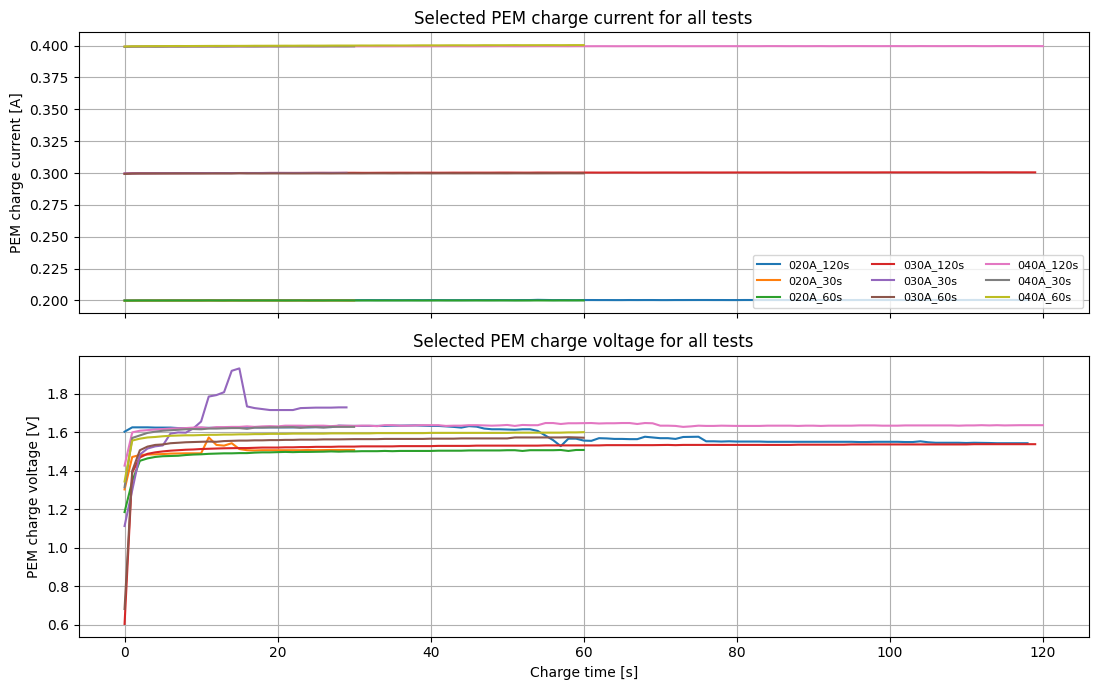

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for file_name, charge in charge_tests.items():
    label = file_name.replace("discharge_", "").replace("_r1.csv", "")

    axes[0].plot(
        charge["charge_time_s"],
        charge["pem_current_A"],
        label=label,
    )

    axes[1].plot(
        charge["charge_time_s"],
        charge["pem_voltage_V"],
        label=label,
    )

axes[0].set_title("Selected PEM charge current for all tests")
axes[0].set_ylabel("PEM charge current [A]")
axes[0].grid(True)

axes[1].set_title("Selected PEM charge voltage for all tests")
axes[1].set_xlabel("Charge time [s]")
axes[1].set_ylabel("PEM charge voltage [V]")
axes[1].grid(True)

axes[0].legend(ncol=3, fontsize=8)
plt.tight_layout()
plt.show()


## 4. Integrate charge and energy for every test


In [12]:
def parse_setpoints(file_name):
    # Example: discharge_040A_120s_r1.csv -> 0.40 A and 120 s.
    parts = file_name.replace(".csv", "").split("_")
    current_A = int(parts[1].replace("A", "")) / 100
    duration_s = int(parts[2].replace("s", ""))
    return current_A, duration_s

rows = []
for file_name, charge in charge_tests.items():
    current_setpoint_A, duration_setpoint_s = parse_setpoints(file_name)
    charge = charge.copy()
    charge["dt_s"] = charge["charge_time_s"].diff().fillna(0)
    #Integrate current and power over time to get total charge and energy input. Coulomb counting and energy counting.
    input_charge_C = (charge["pem_current_A"] * charge["dt_s"]).sum()
    input_energy_J = (charge["pem_charge_power_W"] * charge["dt_s"]).sum()

    volume_match = volume_readings[
        (volume_readings["current_A"] == current_setpoint_A)
        & (volume_readings["time_s"] == duration_setpoint_s)
    ]
    hydrogen_volume_mL = volume_match["volume_mL"].iloc[0]

    rows.append(
        {
            "file": file_name,
            "current_setpoint_A": current_setpoint_A,
            "duration_setpoint_s": duration_setpoint_s,
            "hydrogen_volume_mL": hydrogen_volume_mL,
            "input_charge_C": input_charge_C,
            "input_energy_J": input_energy_J,
            "hydrogen_mL_per_C": hydrogen_volume_mL / input_charge_C,
            "hydrogen_mL_per_J": hydrogen_volume_mL / input_energy_J,
        }
    )

charge_summary = pd.DataFrame(rows).sort_values(["current_setpoint_A", "duration_setpoint_s"])
display(charge_summary)


,file,current_setpoint_A,duration_setpoint_s,hydrogen_volume_mL,input_charge_C,input_energy_J,hydrogen_mL_per_C,hydrogen_mL_per_J
1,discharge_020A_30s_r1.csv,0.2,30,0.2,5.999283,9.026946,0.033337,0.022156
2,discharge_020A_60s_r1.csv,0.2,60,1.6,11.999809,17.924721,0.133335,0.089262
0,discharge_020A_120s_r1.csv,0.2,120,3.0,23.635698,37.491836,0.126927,0.080017
4,discharge_030A_30s_r1.csv,0.3,30,1.6,8.699508,14.687808,0.183918,0.108934
5,discharge_030A_60s_r1.csv,0.3,60,2.2,17.983824,28.006290,0.122332,0.078554
3,discharge_030A_120s_r1.csv,0.3,120,4.2,35.737394,54.565123,0.117524,0.076972
7,discharge_040A_30s_r1.csv,0.4,30,2.2,11.979546,19.370871,0.183646,0.113573
8,discharge_040A_60s_r1.csv,0.4,60,4.0,24.001305,38.185626,0.166658,0.104751
6,discharge_040A_120s_r1.csv,0.4,120,6.0,47.939786,78.303592,0.125157,0.076625


## 5. Compare the rate values


Short-test aggregate H2 production: 0.0840 mL/J
Short-test average H2 charge rate:  0.03968 mL/s
Short-test aggregate H2 production: 0.1330 mL/C
Short-test coulomb efficiency:       106.9 %
A value above 100 percent means these small manual volume readings are noisy.


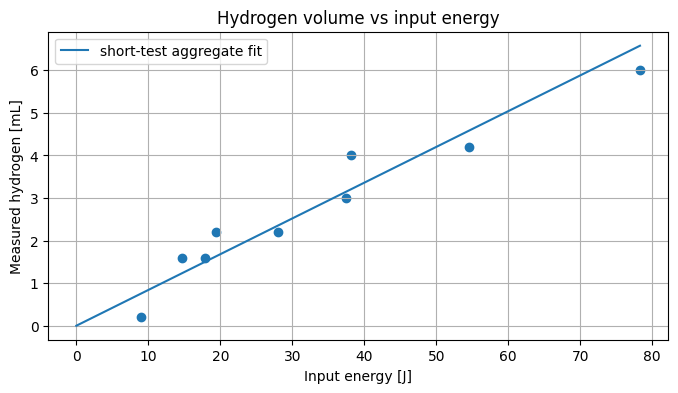

In [20]:
FARADAY_CONSTANT_C_PER_MOL = 96485
ELECTRONS_PER_H2 = 2
MOLAR_VOLUME_H2_ML_PER_MOL = 24000

FARADAY_THEORETICAL_H2_ML_PER_C = (
    MOLAR_VOLUME_H2_ML_PER_MOL
    / (ELECTRONS_PER_H2 * FARADAY_CONSTANT_C_PER_MOL)
)

SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J = (
    charge_summary["hydrogen_volume_mL"].sum() / charge_summary["input_energy_J"].sum()
)
SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_C = (
    charge_summary["hydrogen_volume_mL"].sum() / charge_summary["input_charge_C"].sum()
)

SHORT_TEST_HYDROGEN_CHARGE_RATE_ML_PER_S = (
    charge_summary["hydrogen_volume_mL"].sum() / charge_summary["duration_setpoint_s"].sum()
)

SHORT_TEST_HYDROGEN_COULOMB_EFFICIENCY = (
    SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_C / FARADAY_THEORETICAL_H2_ML_PER_C
)

print(f"Short-test aggregate H2 production: {SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J:.4f} mL/J")
print(f"Short-test average H2 charge rate:  {SHORT_TEST_HYDROGEN_CHARGE_RATE_ML_PER_S:.5f} mL/s")
print(f"Short-test aggregate H2 production: {SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.4f} mL/C")
print(f"Short-test coulomb efficiency:       {100 * SHORT_TEST_HYDROGEN_COULOMB_EFFICIENCY:.1f} %")
print("A value above 100 percent means these small manual volume readings are noisy.")


plt.figure(figsize=(8, 4))
plt.scatter(charge_summary["input_energy_J"], charge_summary["hydrogen_volume_mL"])
x = np.linspace(0, charge_summary["input_energy_J"].max(), 100)
plt.plot(x, SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J * x, label="short-test aggregate fit")
plt.title("Hydrogen volume vs input energy")
plt.xlabel("Input energy [J]")
plt.ylabel("Measured hydrogen [mL]")
plt.grid(True)
plt.legend()
plt.show()


## 6. Use the full 15.6 mL calibration for the EMS value

 The short tests are useful for checking trends, but the volume readings are small and therefore noisy.
 
  For the final EMS production constant I use the larger calibration from the polarization file.

The formulas used in the next code cell are:

input charge: Q = integral(I dt)
input energy: E = integral(V I dt)
hydrogen per energy: H2_per_J = measured_H2 / E
hydrogen per charge: H2_per_C = measured_H2 / Q
average hydrogen charge rate: H2_rate = measured_H2 / charge_time

The mL/s value is an average over this full calibration charge. For a variable EMS input, mL/J is
still the better model value because it follows the actual electrical energy going into the PEM.
            


In [21]:
polarization_file = PROJECT_ROOT / "data/PEM_test/current_sweep/PEM_polarization_characteristics.csv"
polarization = pd.read_csv(polarization_file)

polarization["timestamp"] = pd.to_datetime(polarization["timestamp"])
polarization["time_s"] = (polarization["timestamp"] - polarization["timestamp"].iloc[0]).dt.total_seconds()

polarization["pem_voltage_V"] = polarization["ina4_bus_V"] - 0.064
polarization["pem_current_A"] = 0.843 * (polarization["ina4_current_mA"] / 1000) + 0.001
polarization["pem_charge_power_W"] = polarization["pem_voltage_V"] * polarization["pem_current_A"]


#filter for charge part: scenario 3 or current above 0.01 A, and also above 0.05 A to exclude noise
polarization_charge = polarization[
    (polarization["scenario"] == 3)
    & (polarization["pem_current_A"] > 0.05)
].copy()

# Create a new column for charge time starting from zero at the first charge point
polarization_charge["charge_time_s"] = (
    polarization_charge["time_s"] - polarization_charge["time_s"].iloc[0]
)

# Formula: charge duration t = last selected charge time.
full_charge_duration_s = polarization_charge["charge_time_s"].iloc[-1]

# Formula: input charge Q = integral(I dt), unit C.
full_input_charge_C = np.trapezoid(
    polarization_charge["pem_current_A"],
    polarization_charge["charge_time_s"],
)

# Formula: input energy E = integral(P dt) = integral(V I dt), unit J.
full_input_energy_J = np.trapezoid(
    polarization_charge["pem_charge_power_W"],
    polarization_charge["charge_time_s"],
)

MEASURED_FULL_HYDROGEN_CAPACITY_ML = 15.6

# Formula: H2 produced per input energy = measured H2 / input energy.
HYDROGEN_PRODUCTION_ML_PER_INPUT_J = MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_energy_J

# Formula: H2 produced per input charge = measured H2 / input charge.
HYDROGEN_PRODUCTION_ML_PER_INPUT_C = MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_input_charge_C

# Formula: average H2 charge rate = measured H2 / charge duration.
HYDROGEN_CHARGE_RATE_ML_PER_S = MEASURED_FULL_HYDROGEN_CAPACITY_ML / full_charge_duration_s
HYDROGEN_CHARGE_RATE_ML_PER_MIN = HYDROGEN_CHARGE_RATE_ML_PER_S * 60

# Formula: Faraday efficiency = measured H2 per C / theoretical H2 per C.
HYDROGEN_COULOMB_EFFICIENCY = HYDROGEN_PRODUCTION_ML_PER_INPUT_C / FARADAY_THEORETICAL_H2_ML_PER_C

print(f"Full calibration charge duration: {full_charge_duration_s:.1f} s")
print(f"Full calibration input charge:    {full_input_charge_C:.2f} C")
print(f"Full calibration input energy:    {full_input_energy_J:.2f} J")
print(f"EMS H2 production constant:       {HYDROGEN_PRODUCTION_ML_PER_INPUT_J:.4f} mL/J")
print(f"Average H2 charge rate:           {HYDROGEN_CHARGE_RATE_ML_PER_S:.5f} mL/s")
print(f"Average H2 charge rate:           {HYDROGEN_CHARGE_RATE_ML_PER_MIN:.3f} mL/min")
print(f"Faraday efficiency:               {100 * HYDROGEN_COULOMB_EFFICIENCY:.1f} %")
print(f"H2_ML_PER_C:                      {HYDROGEN_PRODUCTION_ML_PER_INPUT_C:.5f} mL/C")


Full calibration charge duration: 869.0 s
Full calibration input charge:    149.70 C
Full calibration input energy:    219.42 J
EMS H2 production constant:       0.0711 mL/J
Average H2 charge rate:           0.01795 mL/s
Average H2 charge rate:           1.077 mL/min
Faraday efficiency:               83.8 %
H2_ML_PER_C:                      0.10421 mL/C


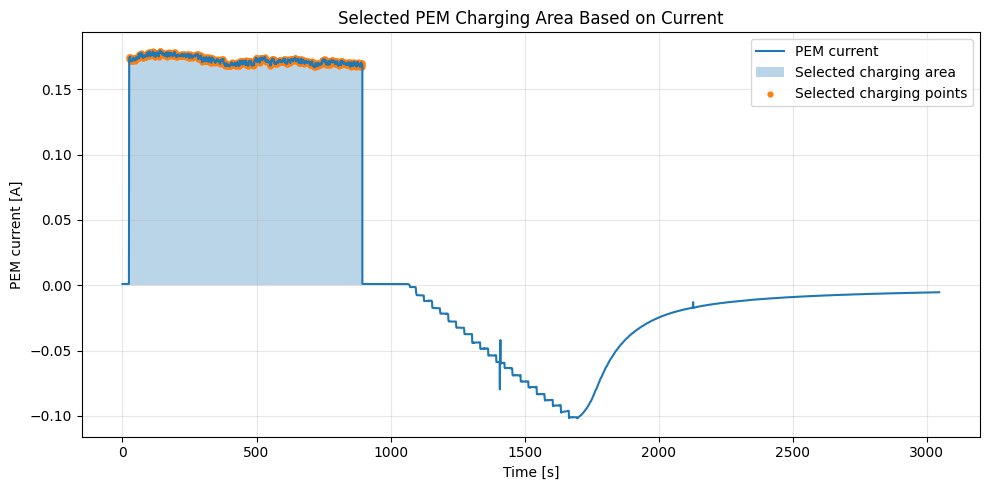

Selected charge duration: 870.0 s
Integrated input charge:  149.86 C


In [22]:
import matplotlib.pyplot as plt
import numpy as np

selection_mask = (
    ((polarization["scenario"] == 3) | (polarization["pem_current_A"] > 0.01))
    & (polarization["pem_current_A"] > 0.05)
)

polarization_charge = polarization[selection_mask].copy()

polarization_charge["charge_time_s"] = (
    polarization_charge["time_s"] - polarization_charge["time_s"].iloc[0]
)

full_charge_duration_s = polarization_charge["charge_time_s"].iloc[-1]

full_input_charge_C = np.trapezoid(
    polarization_charge["pem_current_A"],
    polarization_charge["charge_time_s"]
)

full_input_energy_J = np.trapezoid(
    polarization_charge["pem_charge_power_W"],
    polarization_charge["charge_time_s"]
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    polarization["time_s"],
    polarization["pem_current_A"],
    label="PEM current",
    linewidth=1.5
)

ax.fill_between(
    polarization_charge["time_s"],
    polarization_charge["pem_current_A"],
    alpha=0.3,
    label="Selected charging area"
)

ax.scatter(
    polarization_charge["time_s"],
    polarization_charge["pem_current_A"],
    s=12,
    label="Selected charging points"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("PEM current [A]")
ax.set_title("Selected PEM Charging Area Based on Current")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f"Selected charge duration: {full_charge_duration_s:.1f} s")
print(f"Integrated input charge:  {full_input_charge_C:.2f} C")

The charge rate is plotted for the full duration 

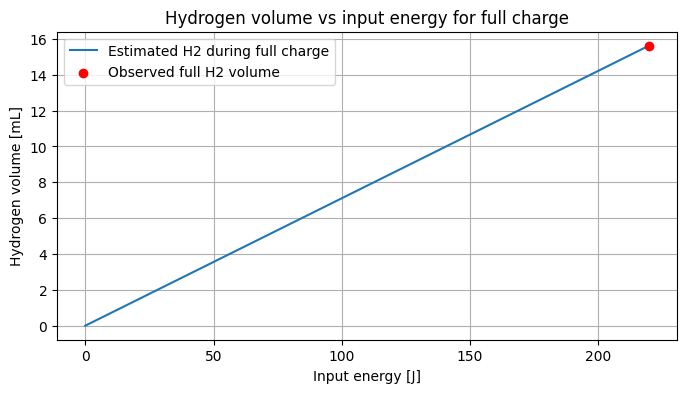

In [27]:
full_cycle_plot = polarization_charge.copy()

# Incremental time step.
full_cycle_plot["dt_s"] = full_cycle_plot["charge_time_s"].diff().fillna(0)

# Trapezoid energy step:
# dE = 0.5 * (P_now + P_previous) * dt
full_cycle_plot["previous_power_W"] = full_cycle_plot["pem_charge_power_W"].shift(1)
full_cycle_plot["previous_power_W"] = full_cycle_plot["previous_power_W"].fillna(full_cycle_plot["pem_charge_power_W"])

full_cycle_plot["dE_J"] = (
    0.5
    * (full_cycle_plot["pem_charge_power_W"] + full_cycle_plot["previous_power_W"])
    * full_cycle_plot["dt_s"]
)

# Cumulative input energy.
full_cycle_plot["input_energy_J"] = full_cycle_plot["dE_J"].cumsum()

# Estimated hydrogen volume from the full-cycle calibration.
full_cycle_plot["hydrogen_volume_mL"] = (
    full_cycle_plot["input_energy_J"] * HYDROGEN_PRODUCTION_ML_PER_INPUT_J
)

plt.figure(figsize=(8, 4))

plt.plot(
    full_cycle_plot["input_energy_J"],
    full_cycle_plot["hydrogen_volume_mL"],
    label="Estimated H2 during full charge",
)

plt.scatter(
    full_input_energy_J,
    MEASURED_FULL_HYDROGEN_CAPACITY_ML,
    color="red",
    zorder=5,
    label="Observed full H2 volume",
)

plt.title("Hydrogen volume vs input energy for full charge")
plt.xlabel("Input energy [J]")
plt.ylabel("Hydrogen volume [mL]")
plt.grid(True)
plt.legend()
plt.show()


The plot below is used to test how the estimation model performs on the tests with smaller duration, to try and validate it for more than full cycles

,file,current_setpoint_A,duration_setpoint_s,input_energy_J,hydrogen_volume_mL,predicted_hydrogen_mL,error_mL,error_percent
1,discharge_020A_30s_r1.csv,0.2,30,9.026946,0.2,0.641074,-0.441074,-220.537099
2,discharge_020A_60s_r1.csv,0.2,60,17.924721,1.6,1.272975,0.327025,20.439063
0,discharge_020A_120s_r1.csv,0.2,120,37.491836,3.0,2.662589,0.337411,11.247025
4,discharge_030A_30s_r1.csv,0.3,30,14.687808,1.6,1.043096,0.556904,34.806475
5,discharge_030A_60s_r1.csv,0.3,60,28.006290,2.2,1.988946,0.211054,9.593351
3,discharge_030A_120s_r1.csv,0.3,120,54.565123,4.2,3.875097,0.324903,7.735780
7,discharge_040A_30s_r1.csv,0.4,30,19.370871,2.2,1.375677,0.824323,37.469206
8,discharge_040A_60s_r1.csv,0.4,60,38.185626,4.0,2.711861,1.288139,32.203483
6,discharge_040A_120s_r1.csv,0.4,120,78.303592,6.0,5.560952,0.439048,7.317467


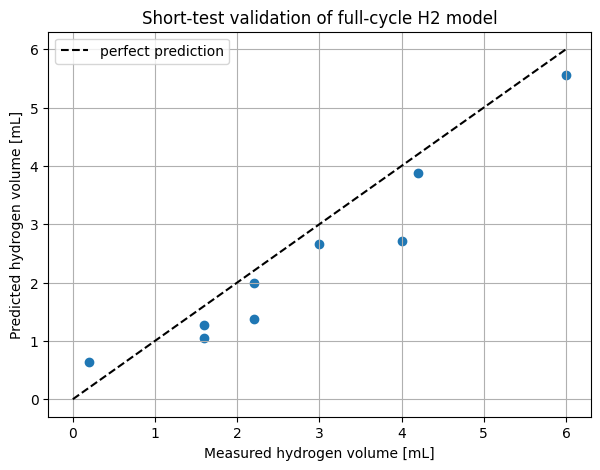

In [16]:
validation = charge_summary.copy()

# Predict H2 in each short test using the full-cycle energy calibration.
validation["predicted_hydrogen_mL"] = (
    validation["input_energy_J"] * HYDROGEN_PRODUCTION_ML_PER_INPUT_J
)

# Difference between measured and predicted H2.
validation["error_mL"] = (
    validation["hydrogen_volume_mL"] - validation["predicted_hydrogen_mL"]
)

validation["error_percent"] = (
    100 * validation["error_mL"] / validation["hydrogen_volume_mL"]
)

display(
    validation[
        [
            "file",
            "current_setpoint_A",
            "duration_setpoint_s",
            "input_energy_J",
            "hydrogen_volume_mL",
            "predicted_hydrogen_mL",
            "error_mL",
            "error_percent",
        ]
    ]
)

plt.figure(figsize=(7, 5))

plt.scatter(
    validation["hydrogen_volume_mL"],
    validation["predicted_hydrogen_mL"],
)

max_volume = max(
    validation["hydrogen_volume_mL"].max(),
    validation["predicted_hydrogen_mL"].max(),
)

plt.plot(
    [0, max_volume],
    [0, max_volume],
    linestyle="--",
    color="black",
    label="perfect prediction",
)

plt.title("Short-test validation of full-cycle H2 model")
plt.xlabel("Measured hydrogen volume [mL]")
plt.ylabel("Predicted hydrogen volume [mL]")
plt.grid(True)
plt.legend()
plt.show()


The Long test underpredicts the charging test made for shorter durations and different charge current. Therefore a tradeoff between long term behavior and short term variations will be hard to come around. 

### Discharge rate estimation 

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Select all negative-current discharge points
discharge_all = polarization[
    polarization["pem_current_A"] < -0.005
].copy()

# Find the most negative current point
idx_min_current = discharge_all["pem_current_A"].idxmin()
t_min_current = polarization.loc[idx_min_current, "time_s"]

# Find start time of discharge
t_discharge_start = discharge_all["time_s"].iloc[0]

# Select active discharge region:
# from first negative current point until minimum current point
active_discharge = polarization[
    (polarization["time_s"] >= t_discharge_start)
    & (polarization["time_s"] <= t_min_current)
    & (polarization["pem_current_A"] < -0.005)
].copy()

# Local time axis starting at 0
active_discharge["discharge_time_s"] = (
    active_discharge["time_s"] - active_discharge["time_s"].iloc[0]
)

# Use positive current magnitude for integration
active_discharge["pem_discharge_current_A"] = (
    -active_discharge["pem_current_A"]
)

# Positive PEM output power
active_discharge["pem_discharge_power_W"] = (
    active_discharge["pem_voltage_V"]
    * active_discharge["pem_discharge_current_A"]
)

# Duration of active discharge
active_discharge_duration_s = active_discharge["discharge_time_s"].iloc[-1]

# Output charge during active discharge
active_output_charge_C = np.trapezoid(
    active_discharge["pem_discharge_current_A"],
    active_discharge["discharge_time_s"]
)

# Output energy during active discharge
active_output_energy_J = np.trapezoid(
    active_discharge["pem_discharge_power_W"],
    active_discharge["discharge_time_s"]
)

# Measured hydrogen values
MEASURED_FULL_HYDROGEN_CAPACITY_ML = 15.6
MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML = 7.6

MEASURED_USABLE_HYDROGEN_DISCHARGE_ML = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML
    - MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML
)

# Discharge constants
HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_output_charge_C
)

HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_output_energy_J
)

HYDROGEN_DISCHARGE_RATE_ML_PER_S = (
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML / active_discharge_duration_s
)

HYDROGEN_DISCHARGE_RATE_ML_PER_MIN = (
    HYDROGEN_DISCHARGE_RATE_ML_PER_S * 60
)

print(f"Active discharge start:             {t_discharge_start:.1f} s")
print(f"Minimum current time:               {t_min_current:.1f} s")
print(f"Active discharge duration:          {active_discharge_duration_s:.1f} s")
print(f"Active discharge output charge:     {active_output_charge_C:.2f} C")
print(f"Active discharge output energy:     {active_output_energy_J:.2f} J")
print(f"Hydrogen used:                      {MEASURED_USABLE_HYDROGEN_DISCHARGE_ML:.2f} mL")
print(f"H2 discharge constant:              {HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C:.5f} mL/C")
print(f"H2 discharge energy constant:       {HYDROGEN_DISCHARGE_ML_PER_OUTPUT_J:.5f} mL/J")
print(f"Average H2 discharge rate:          {HYDROGEN_DISCHARGE_RATE_ML_PER_S:.5f} mL/s")
print(f"Average H2 discharge rate:          {HYDROGEN_DISCHARGE_RATE_ML_PER_MIN:.3f} mL/min")

Active discharge start:             1096.0 s
Minimum current time:               1697.0 s
Active discharge duration:          601.0 s
Active discharge output charge:     33.41 C
Active discharge output energy:     17.12 J
Hydrogen used:                      8.00 mL
H2 discharge constant:              0.23948 mL/C
H2 discharge energy constant:       0.46720 mL/J
Average H2 discharge rate:          0.01331 mL/s
Average H2 discharge rate:          0.799 mL/min


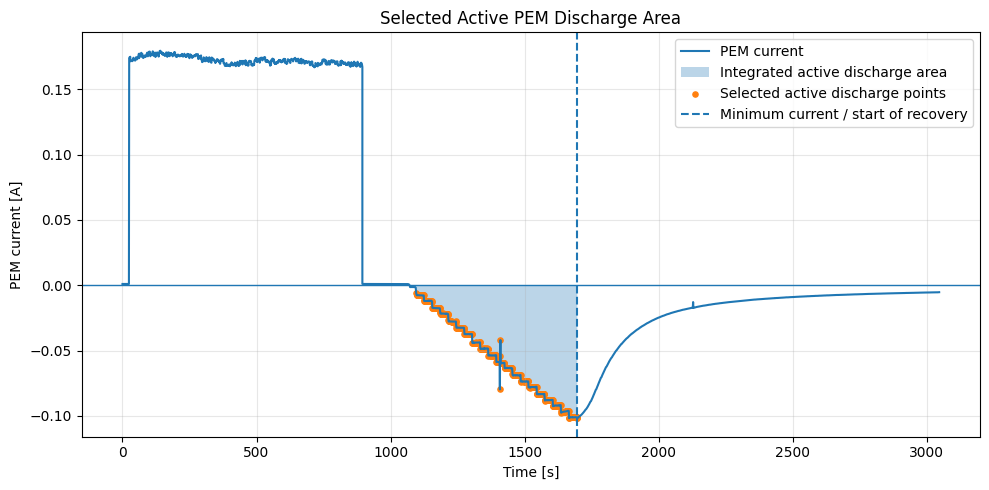

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    polarization["time_s"],
    polarization["pem_current_A"],
    label="PEM current",
    linewidth=1.5
)

ax.fill_between(
    active_discharge["time_s"],
    active_discharge["pem_current_A"],
    0,
    alpha=0.3,
    label="Integrated active discharge area"
)

ax.scatter(
    active_discharge["time_s"],
    active_discharge["pem_current_A"],
    s=14,
    label="Selected active discharge points"
)

ax.axvline(
    t_min_current,
    linestyle="--",
    label="Minimum current / start of recovery"
)

ax.axhline(0, linewidth=1)

ax.set_xlabel("Time [s]")
ax.set_ylabel("PEM current [A]")
ax.set_title("Selected Active PEM Discharge Area")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

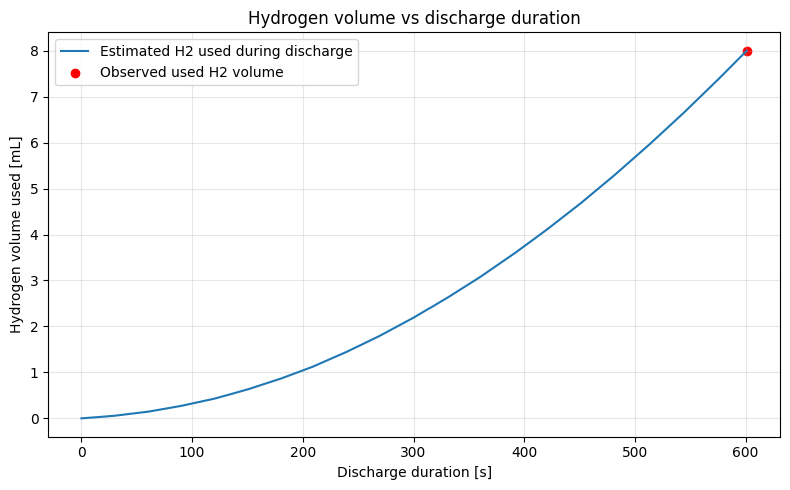

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Measured hydrogen volumes
MEASURED_FULL_HYDROGEN_CAPACITY_ML = 15.6
MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML = 7.6
MEASURED_USABLE_HYDROGEN_DISCHARGE_ML = (
    MEASURED_FULL_HYDROGEN_CAPACITY_ML
    - MEASURED_REMAINING_HYDROGEN_AFTER_DISCHARGE_ML
)

# Time and discharge current
t = active_discharge["discharge_time_s"].to_numpy()
I = active_discharge["pem_discharge_current_A"].to_numpy()

# Cumulative discharged charge using trapezoidal integration
dt = np.diff(t)
cumulative_charge_C = np.concatenate([
    [0],
    np.cumsum(0.5 * (I[:-1] + I[1:]) * dt)
])

# Total discharged charge
total_discharge_charge_C = cumulative_charge_C[-1]

# Convert cumulative charge to estimated discharged hydrogen volume
estimated_h2_used_mL = (
    cumulative_charge_C / total_discharge_charge_C
) * MEASURED_USABLE_HYDROGEN_DISCHARGE_ML

# Plot
plt.figure(figsize=(8, 5))

plt.plot(
    t,
    estimated_h2_used_mL,
    label="Estimated H2 used during discharge"
)

plt.scatter(
    t[-1],
    MEASURED_USABLE_HYDROGEN_DISCHARGE_ML,
    color="red",
    label="Observed used H2 volume"
)

plt.xlabel("Discharge duration [s]")
plt.ylabel("Hydrogen volume used [mL]")
plt.title("Hydrogen volume vs discharge duration")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Values to use in the EMS


In [17]:
MAXIMUM_ELECTROLYSIS_CURRENT_A = charge_summary["current_setpoint_A"].max()
MINIMUM_CHARGE_TIME_BEFORE_USEFUL_DISCHARGE_S = charge_summary["duration_setpoint_s"].min()

charge_parameters = pd.DataFrame(
    {
        "parameter": [
            "MEASURED_FULL_HYDROGEN_CAPACITY_ML",
            "HYDROGEN_PRODUCTION_ML_PER_INPUT_J",
            "HYDROGEN_PRODUCTION_ML_PER_INPUT_C",
            "HYDROGEN_CHARGE_RATE_ML_PER_S",
            "HYDROGEN_CHARGE_RATE_ML_PER_MIN",
            "HYDROGEN_COULOMB_EFFICIENCY",
            "SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J",
            "MAXIMUM_ELECTROLYSIS_CURRENT_A",
            "MINIMUM_CHARGE_TIME_BEFORE_USEFUL_DISCHARGE_S",
        ],
        "value": [
            MEASURED_FULL_HYDROGEN_CAPACITY_ML,
            HYDROGEN_PRODUCTION_ML_PER_INPUT_J,
            HYDROGEN_PRODUCTION_ML_PER_INPUT_C,
            HYDROGEN_CHARGE_RATE_ML_PER_S,
            HYDROGEN_CHARGE_RATE_ML_PER_MIN,
            HYDROGEN_COULOMB_EFFICIENCY,
            SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J,
            MAXIMUM_ELECTROLYSIS_CURRENT_A,
            MINIMUM_CHARGE_TIME_BEFORE_USEFUL_DISCHARGE_S,
        ],
        "unit": ["mL", "mL/J", "mL/C", "mL/s", "mL/min", "-", "mL/J", "A", "s"],
        "meaning": [
            "Measured full tank volume used for the demo",
            "Hydrogen produced per electrical input energy from full calibration",
            "Hydrogen produced per input charge from full calibration",
            "Average hydrogen production rate during the full calibration charge",
            "Same average rate converted to mL/min for readability",
            "Full calibration efficiency relative to Faraday estimate",
            "Short-test value shown only as a noisy comparison",
            "Largest tested electrolysis current",
            "Smallest tested charge duration that produced measurable H2",
        ],
    }
)

display(charge_parameters)


,parameter,value,unit,meaning
0,MEASURED_FULL_HYDROGEN_CAPACITY_ML,15.600000,mL,Measured full tank volume used for the demo
1,HYDROGEN_PRODUCTION_ML_PER_INPUT_J,0.071018,mL/J,Hydrogen produced per electrical input energy ...
2,HYDROGEN_PRODUCTION_ML_PER_INPUT_C,0.104095,mL/C,Hydrogen produced per input charge from full c...
3,HYDROGEN_CHARGE_RATE_ML_PER_S,0.017931,mL/s,Average hydrogen production rate during the fu...
4,HYDROGEN_CHARGE_RATE_ML_PER_MIN,1.075862,mL/min,Same average rate converted to mL/min for read...
5,HYDROGEN_COULOMB_EFFICIENCY,0.821068,-,Full calibration efficiency relative to Farada...
6,SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J,0.084016,mL/J,Short-test value shown only as a noisy comparison
7,MAXIMUM_ELECTROLYSIS_CURRENT_A,0.400000,A,Largest tested electrolysis current
8,MINIMUM_CHARGE_TIME_BEFORE_USEFUL_DISCHARGE_S,30.000000,s,Smallest tested charge duration that produced ...


Validating the short test on the long test 

Predicted full-cycle H2 from short-test model: 18.46 mL
Measured full-cycle H2:                        15.60 mL
Error:                                         2.86 mL (18.3 %)


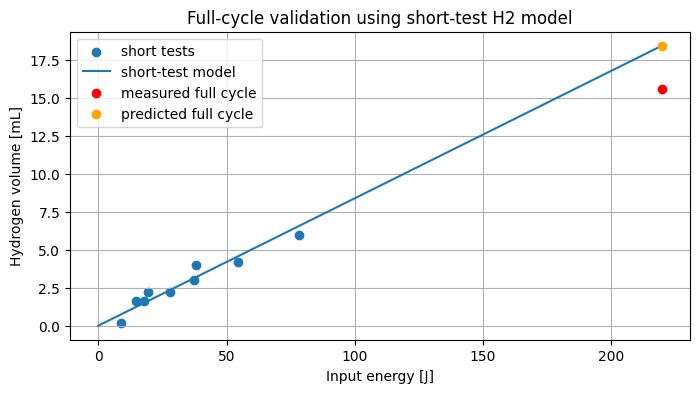

In [18]:
predicted_full_H2_from_short_model_mL = (
    SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J * full_input_energy_J
)

full_cycle_error_mL = (
    predicted_full_H2_from_short_model_mL - MEASURED_FULL_HYDROGEN_CAPACITY_ML
)

full_cycle_error_percent = (
    100 * full_cycle_error_mL / MEASURED_FULL_HYDROGEN_CAPACITY_ML
)

print(f"Predicted full-cycle H2 from short-test model: {predicted_full_H2_from_short_model_mL:.2f} mL")
print(f"Measured full-cycle H2:                        {MEASURED_FULL_HYDROGEN_CAPACITY_ML:.2f} mL")
print(f"Error:                                         {full_cycle_error_mL:.2f} mL ({full_cycle_error_percent:.1f} %)")

plt.figure(figsize=(8, 4))

plt.scatter(
    charge_summary["input_energy_J"],
    charge_summary["hydrogen_volume_mL"],
    label="short tests",
)

x = np.linspace(0, full_input_energy_J, 100)

plt.plot(
    x,
    SHORT_TEST_HYDROGEN_PRODUCTION_ML_PER_INPUT_J * x,
    label="short-test model",
)

plt.scatter(
    full_input_energy_J,
    MEASURED_FULL_HYDROGEN_CAPACITY_ML,
    color="red",
    zorder=5,
    label="measured full cycle",
)

plt.scatter(
    full_input_energy_J,
    predicted_full_H2_from_short_model_mL,
    color="orange",
    zorder=5,
    label="predicted full cycle",
)

plt.title("Full-cycle validation using short-test H2 model")
plt.xlabel("Input energy [J]")
plt.ylabel("Hydrogen volume [mL]")
plt.grid(True)
plt.legend()
plt.show()


The short charge tests show the same general linear trend between input energy and hydrogen volume, but they overpredict the full-cycle hydrogen production. Since the EMS should avoid overestimating stored hydrogen, the full-cycle calibration is developed to see if it fits better 

We will convert these rates into an estimator that estimates the hydrogen volume during charge and discharge 

In [ ]:
HYDROGEN_PRODUCTION_ML_PER_INPUT_C = 0.104095      # mL/C during charging
HYDROGEN_DISCHARGE_ML_PER_OUTPUT_C = 0.23948   # mL/C during discharge

H2_MAX_ML = 15.6
H2_MIN_USABLE_ML = 7.6
H2_USABLE_ML = H2_MAX_ML - H2_MIN_USABLE_ML


usable_soc = (h2_volume_mL - 7.6) / (15.6 - 7.6)


In [30]:
from dataclasses import dataclass
import time


@dataclass
class HydrogenEstimatorConfig:
    h2_max_mL: float = 15.6
    h2_min_usable_mL: float = 7.6

    h2_charge_mL_per_C: float = 0.104095
    h2_discharge_mL_per_C: float = 0.25175648

    charge_current_threshold_A: float = 0.01
    discharge_current_threshold_A: float = -0.005


class HydrogenEstimator:
    def __init__(self, config=HydrogenEstimatorConfig(), initial_h2_mL=7.6):
        self.config = config
        self.h2_mL = initial_h2_mL
        self.last_update_s = None

    def update(self, pem_current_A, now_s=None):
        if now_s is None:
            now_s = time.time()

        if self.last_update_s is None:
            self.last_update_s = now_s
            return self.get_state()

        dt_s = now_s - self.last_update_s
        self.last_update_s = now_s

        if dt_s <= 0:
            return self.get_state()

        if pem_current_A > self.config.charge_current_threshold_A:
            charge_C = pem_current_A * dt_s

            h2_added_mL = (
                charge_C
                * self.config.h2_charge_mL_per_C
            )

            self.h2_mL += h2_added_mL

        elif pem_current_A < self.config.discharge_current_threshold_A:
            discharge_C = abs(pem_current_A) * dt_s

            h2_used_mL = (
                discharge_C
                * self.config.h2_discharge_mL_per_C
            )

            self.h2_mL -= h2_used_mL

        self.h2_mL = max(
            self.config.h2_min_usable_mL,
            min(self.h2_mL, self.config.h2_max_mL)
        )

        return self.get_state()

    def get_state(self):
        usable_range_mL = (
            self.config.h2_max_mL
            - self.config.h2_min_usable_mL
        )

        usable_soc = (
            (self.h2_mL - self.config.h2_min_usable_mL)
            / usable_range_mL
        )

        usable_soc = max(0.0, min(1.0, usable_soc))

        return {
            "h2_mL": self.h2_mL,
            "usable_h2_mL": self.h2_mL - self.config.h2_min_usable_mL,
            "usable_soc": usable_soc,
            "usable_soc_percent": usable_soc * 100,
        }

In [ ]:
h2_estimator = HydrogenEstimator(initial_h2_mL=7.6)

while True:
    pem_current_A = measured_pem_current_A

    h2_state = h2_estimator.update(pem_current_A)

    h2_volume_mL = h2_state["h2_mL"]
    h2_soc_percent = h2_state["usable_soc_percent"]

    print(f"H2 volume: {h2_volume_mL:.2f} mL")
    print(f"H2 usable SOC: {h2_soc_percent:.1f} %")

In [ ]:
if h2_state["usable_soc"] > 0.2:
    pem_can_discharge = True
else:
    pem_can_discharge = False

In [ ]:
if h2_state["usable_soc"] > 0.2:
    pem_can_discharge = True
else:
    pem_can_discharge = False